In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
# import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import sklearn as sk
# pd.options.display.float_format = '{:.2f}'.format
pd.options.display.float_format = '{:.2f}'.format

In [ ]:
import plotly.express as px
import seaborn as sns

In [ ]:
df = pd.read_csv('dataset.csv')
df.head()

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed
0,S00001,12.50,NaN,75.00,Yes,Master,Yes
1,S00002,9.30,95.30,60.60,No,High School,No
2,S00003,13.20,NaN,64.00,No,Associate,No
3,S00004,17.60,76.80,62.40,Yes,Bachelor,No
4,S00005,8.80,89.30,72.70,No,Master,No


In [ ]:
df.shape

(40000, 7)

In [ ]:
df.isna().values.any()

np.True_

In [ ]:
df.duplicated().values.any()

np.False_

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 7 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Student ID                                   40000 non-null  object 
 1   Study Hours per Week                         38005 non-null  float64
 2   Attendance Rate                              38008 non-null  float64
 3   Previous Grades                              38006 non-null  float64
 4   Participation in Extracurricular Activities  38000 non-null  object 
 5   Parent Education Level                       38000 non-null  object 
 6   Passed                                       38000 non-null  object 
dtypes: float64(3), object(4)
memory usage: 2.1+ MB


In [ ]:
df['Attendance Rate'] = df.groupby(['Study Hours per Week', 'Previous Grades'], as_index=False)['Attendance Rate'].transform(lambda x:x.fillna(x.mean()))

In [ ]:
df.sample(10)

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed
4556,S04557,5.00,55.70,54.00,Yes,Bachelor,Yes
21683,S21684,3.40,59.30,30.60,Yes,Associate,No
4414,S04415,11.00,142.60,67.50,No,Bachelor,No
24356,S24357,7.50,NaN,NaN,No,High School,Yes
9391,S09392,17.60,72.60,72.20,No,High School,Yes
11068,S11069,17.40,55.30,50.70,Yes,High School,No
2397,S02398,5.00,NaN,72.70,Yes,Bachelor,Yes
11858,S11859,NaN,NaN,67.60,Yes,Master,No
14661,S14662,16.00,78.30,57.80,No,Master,Yes
16520,S16521,10.40,NaN,55.80,No,Doctorate,Yes


In [ ]:
df[df['Parent Education Level'] == 10.00]

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed


In [ ]:
df.groupby(['Study Hours per Week', 'Previous Grades'], as_index=False)['Attendance Rate'].size()

,Study Hours per Week,Previous Grades,size
0,-12.30,49.90,1
1,-9.60,81.10,1
2,-9.20,64.30,1
3,-8.40,88.60,1
4,-8.30,73.40,1
...,...,...,...
30253,28.60,52.10,1
30254,29.30,55.10,1
30255,29.60,64.50,1
30256,29.70,42.00,1


Here's how you can fetch data from your `df` DataFrame based on multiple conditions using logical operators. I'll use the 'Study Hours per Week', 'Attendance Rate', and 'Previous Grades' columns as examples.

In [ ]:
# df[df['Student ID' == ]]
req_data = df.query('`Previous Grades`.isna() and `Study Hours per Week`.isna() and `Attendance Rate`.isna()')
len(req_data)

101

In [ ]:
df = df[~ df['Student ID'].isin(req_data['Student ID'])]

In [ ]:
df.isna().values.any()

np.True_

In [ ]:
attendance_null = df[df['Attendance Rate'].isna()]
len(attendance_null)

5029

In [ ]:
study_null = df[df['Study Hours per Week'].isna()]
len(study_null)

1894

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39899 entries, 0 to 39999
Data columns (total 7 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Student ID                                   39899 non-null  object 
 1   Study Hours per Week                         38005 non-null  float64
 2   Attendance Rate                              34870 non-null  float64
 3   Previous Grades                              38006 non-null  float64
 4   Participation in Extracurricular Activities  37905 non-null  object 
 5   Parent Education Level                       37905 non-null  object 
 6   Passed                                       37906 non-null  object 
dtypes: float64(3), object(4)
memory usage: 2.4+ MB


###  Handling Study Hours per Week

In [ ]:
isinstance(df['Study Hours per Week'], float)

False

In [ ]:
df['Study Hours per Week'] = df['Study Hours per Week'].astype(float)

In [ ]:
# vals = df['Study Hours per Week'].where(
#      df['Study Hours per Week'] == 'median_study_hours'
df['Study Hours per Week'].sample(10)

,Study Hours per Week
8800,5.90
33731,NaN
9707,15.00
20437,3.60
1732,9.90
1303,6.20
29699,7.40
6750,14.50
10960,-4.90
21911,9.10


In [ ]:
zero_ones = df[df['Study Hours per Week']  == 0].index
df.drop(zero_ones, inplace=True)

In [ ]:
print(df['Study Hours per Week'].isna().values.any())
# df.drop(df[df['Study Hours per Week'] < 0].index, inplace=True)

True


In [ ]:
df[df['Study Hours per Week'] == 'median_study_hours']

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed


In [ ]:
df[df['Study Hours per Week'] == 0]

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed


In [ ]:
median_study_hours = df['Study Hours per Week'].astype('float').median()
print(median_study_hours)

df.fillna({'Study Hours per Week': median_study_hours}, inplace=True)

missing_study_hours = df['Study Hours per Week'].isna().sum()
print(f"Number of missing values in 'Study Hours per Week' after median imputation: {missing_study_hours}")

df.isna().values.any()

10.0
Number of missing values in 'Study Hours per Week' after median imputation: 0


np.True_

In [ ]:
df['Study Hours per Week'].isna().sum() # Study Hours per week done

np.int64(0)

In [ ]:
df.head()

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed
0,S00001,12.50,89.00,75.00,Yes,Master,Yes
1,S00002,9.30,95.30,60.60,No,High School,No
2,S00003,13.20,64.30,64.00,No,Associate,No
3,S00004,17.60,76.80,62.40,Yes,Bachelor,No
4,S00005,8.80,89.30,72.70,No,Master,No


### Handling Attendace Rates

In [ ]:
df[df['Attendance Rate'].isna()] # as a single group of vals are full of nulls the mean computation just doesn't make sense so using the median

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed
25,S00026,10.60,NaN,58.30,No,Doctorate,Yes
40,S00041,10.00,NaN,63.80,Yes,Master,Yes
53,S00054,13.10,NaN,NaN,No,NaN,Yes
82,S00083,17.40,NaN,39.80,No,Master,No
91,S00092,14.80,NaN,76.50,Yes,High School,Yes
...,...,...,...,...,...,...,...
39954,S39955,10.00,NaN,28.90,Yes,High School,No
39961,S39962,14.10,NaN,NaN,No,Master,No
39964,S39965,6.70,NaN,NaN,Yes,Doctorate,No
39990,S39991,19.10,NaN,94.90,No,NaN,Yes


In [ ]:
median_attendance = df['Attendance Rate'].median()

df.fillna({'Attendance Rate': median_attendance}, inplace=True)

print('Null vals after replacing in Attendance Rate:', df['Attendance Rate'].isna().sum())

df.isna().values.any()

Null vals after replacing in Attendance Rate: 0


np.True_

In [ ]:
df['Attendance Rate'] = df['Attendance Rate'].where(
     df['Attendance Rate'] <= 100, other=None
 )

In [ ]:
df.fillna({'Attendance Rate':df['Attendance Rate'].median()}, inplace=True)

In [ ]:
df[df['Attendance Rate']> 100]

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed


###### These are just useless values so dropping

In [ ]:
df[df['Attendance Rate'] < 0]
indices_ = df[df['Attendance Rate'] < 0].index
indices_
df.drop(indices_, inplace=True)

### Handling the Participation in Extracurricular Activities

In [ ]:
df['Participation in Extracurricular Activities'].isna().values.any()

np.True_

In [ ]:
df[df['Participation in Extracurricular Activities'].isna()]

df.fillna({'Participation in Extracurricular Activities':'No'}, inplace=True)

df['Participation in Extracurricular Activities'].isna().sum()

np.int64(0)

In [ ]:
df.sample(10)

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed
20335,S20336,7.30,34.80,84.30,No,Doctorate,Yes
32185,S32186,-0.40,75.30,NaN,No,Bachelor,Yes
629,S00630,15.50,81.70,65.50,No,Associate,NaN
31540,S31541,10.50,84.60,81.70,Yes,High School,No
4083,S04084,0.40,97.80,74.20,Yes,Doctorate,Yes
2052,S02053,6.70,81.00,76.40,No,NaN,No
29649,S29650,19.30,75.30,73.00,Yes,Master,Yes
19016,S19017,11.60,76.40,63.20,Yes,Associate,No
15215,S15216,18.30,65.00,71.30,Yes,Master,Yes
26064,S26065,0.30,83.90,48.80,No,Bachelor,Yes


### Handling Parent Eduation Level

In [ ]:
df[df['Parent Education Level'].isna()].head()

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed
13,S00014,0.40,75.10,50.40,No,NaN,Yes
43,S00044,8.50,81.60,94.10,Yes,NaN,No
53,S00054,13.10,75.30,NaN,No,NaN,Yes
54,S00055,15.20,96.10,49.30,Yes,NaN,NaN
57,S00058,8.50,73.60,60.10,Yes,NaN,No


In [ ]:
df.fillna({'Parent Education Level':'No Education'}, inplace=True)

print(df['Parent Education Level'].isna().values.sum())

df.isna().values.any()

0


np.True_

### Handling Previous Grades

In [ ]:
df['Previous Grades'].isna().sum()

np.int64(1891)

In [ ]:
df.head()

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed
0,S00001,12.50,89.00,75.00,Yes,Master,Yes
1,S00002,9.30,95.30,60.60,No,High School,No
2,S00003,13.20,64.30,64.00,No,Associate,No
3,S00004,17.60,76.80,62.40,Yes,Bachelor,No
4,S00005,8.80,89.30,72.70,No,Master,No


In [ ]:
# Here I'm filling the null values present in the previous grades by grouping with the help of other features
df['Previous Grades'] = df.groupby(['Study Hours per Week',
                                    'Attendance Rate',
                                    'Participation in Extracurricular Activities',
                                    'Parent Education Level'],
                                    as_index=False)['Previous Grades'].transform(lambda x:x.fillna(x.mean()))

In [ ]:
print('After computing grouped previous grades vals the null vals are:', df['Previous Grades'].isna().sum())

After computing grouped previous grades vals the null vals are: 281


In [ ]:
df[df['Previous Grades'].isna()]

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed
147,S00148,3.40,75.30,NaN,Yes,Associate,No
167,S00168,19.50,75.30,NaN,Yes,Doctorate,NaN
221,S00222,0.70,75.30,NaN,No,High School,Yes
382,S00383,-0.60,75.30,NaN,Yes,Master,Yes
436,S00437,18.10,75.30,NaN,No,High School,Yes
...,...,...,...,...,...,...,...
39357,S39358,6.80,75.30,NaN,Yes,Doctorate,Yes
39441,S39442,20.40,75.30,NaN,Yes,No Education,No
39749,S39750,-1.00,75.30,NaN,Yes,High School,No
39866,S39867,16.90,75.30,NaN,Yes,Master,Yes


In [ ]:
drop_prev_grades = df[df['Previous Grades'].isna()].index
print(drop_prev_grades, len(drop_prev_grades))
# df.drop(drop_prev_grades, inplace=True)

Index([  147,   167,   221,   382,   436,   445,   455,   566,   661,   889,
       ...
       38718, 38752, 38820, 38899, 39265, 39357, 39441, 39749, 39866, 39932],
      dtype='int64', length=281) 281


In [ ]:
len(drop_prev_grades) / len(df) *100

0.7050204481019645

In [ ]:
median_previous_grades = df['Previous Grades'].median() #Why median, because it preserves the data and also fills the null vals efficiently
df.fillna({'Previous Grades':median_previous_grades}, inplace=True)

print('Number of missing values in Previous Grades after median imputation:', df['Previous Grades'].isna().sum())

Number of missing values in Previous Grades after median imputation: 0


In [ ]:
df[df['Previous Grades'] > 100]

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed
97,S00098,11.30,67.30,200.00,Yes,Master,Yes
185,S00186,13.60,59.40,102.00,Yes,High School,No
318,S00319,11.60,75.30,200.00,Yes,Bachelor,Yes
377,S00378,10.90,71.50,200.00,Yes,No Education,Yes
585,S00586,11.20,62.70,200.00,Yes,Associate,Yes
...,...,...,...,...,...,...,...
39571,S39572,10.50,95.20,104.90,Yes,Bachelor,No
39705,S39706,5.10,89.70,100.90,Yes,Bachelor,No
39709,S39710,7.40,68.20,102.50,Yes,Doctorate,Yes
39797,S39798,14.60,90.00,107.20,No,Doctorate,No


In [ ]:
indices = df[df['Previous Grades'] > 100].index
df.drop(indices, inplace=True)
indices

Index([   97,   185,   318,   377,   585,   637,   729,   739,   752,   811,
       ...
       39397, 39433, 39511, 39516, 39557, 39571, 39705, 39709, 39797, 39890],
      dtype='int64', length=486)

In [ ]:
len(indices) / len(df) * 100

1.2344111147799142

### Handling any negative values Present in Any of the float type columns

In [ ]:
print('Study Hours per Week any neg vals:' , df[df['Study Hours per Week'] < 0].index)
print('Attendance Rate any neg vals:',df[df['Attendance Rate'] < 0].index)
print('Previous Grades any neg vals:',df[df['Previous Grades'] < 0].index)

Study Hours per Week any neg vals: Index([   74,   236,   262,   366,   382,   431,   442,   452,   471,   544,
       ...
       39434, 39495, 39499, 39517, 39527, 39583, 39616, 39713, 39749, 39931],
      dtype='int64', length=926)
Attendance Rate any neg vals: Index([], dtype='int64')
Previous Grades any neg vals: Index([], dtype='int64')


In [ ]:
print(len(df[df['Study Hours per Week'] < 0]))
neg_study_hrs = df[df['Study Hours per Week'] < 0].index
df.drop(neg_study_hrs, inplace=True)

926


### Handling Passed

In [ ]:
df['Passed'].isna().sum()

np.int64(1928)

In [ ]:
df['Passed'] = df.groupby(['Study Hours per Week',
                              'Attendance Rate',
                              'Previous Grades',
                              'Participation in Extracurricular Activities',
                              'Parent Education Level'],
                                as_index=False)['Passed'].transform(lambda x:x.fillna(x.mode()[0] if not x.mode().empty else x))


/tmp/ipykernel_5339/149948446.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  as_index=False)['Passed'].transform(lambda x:x.fillna(x.mode()[0] if not x.mode().empty else x))


In [ ]:
df['Passed'].isna().values.sum()

np.int64(1823)

In [ ]:
len(df[df['Passed'].isna()]) / len(df) * 100

4.74183899076603

In [ ]:
global_passed_mode = df['Passed'].mode()[0]
df['Passed'] = df['Passed'].fillna(global_passed_mode)

missing_passed_values = df['Passed'].isna().sum()
print(f"Number of missing values in 'Passed' after imputation: {missing_passed_values}")

# Check overall missing values again
display(df.isna().sum())

Number of missing values in 'Passed' after imputation: 0


,0
Student ID,0
Study Hours per Week,0
Attendance Rate,0
Previous Grades,0
Participation in Extracurricular Activities,0
Parent Education Level,0
Passed,0


## **All of the null values and Duplicated values are Handled**

In [ ]:
df.head()

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed
0,S00001,12.50,89.00,75.00,Yes,Master,Yes
1,S00002,9.30,95.30,60.60,No,High School,No
2,S00003,13.20,64.30,64.00,No,Associate,No
3,S00004,17.60,76.80,62.40,Yes,Bachelor,No
4,S00005,8.80,89.30,72.70,No,Master,No


# **ANALYSIS**

In [ ]:
d_t_plot = df.groupby('Parent Education Level', as_index=False).size().sort_values(ascending=False, by='size')

In [ ]:
d_t_plot

,Parent Education Level,size
3,High School,7395
1,Bachelor,7382
0,Associate,7328
2,Doctorate,7297
4,Master,7129
5,No Education,1914


In [ ]:
bar = px.bar(d_t_plot, x='Parent Education Level',
                       y='size',
                       title='Parent edu lev v/s Passed',
                       color='Parent Education Level')
bar.update_layout(xaxis_title='Parent Education Level', yaxis_title='Passed')
bar.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38445 entries, 0 to 39999
Data columns (total 7 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Student ID                                   38445 non-null  object 
 1   Study Hours per Week                         38445 non-null  float64
 2   Attendance Rate                              38445 non-null  float64
 3   Previous Grades                              38445 non-null  float64
 4   Participation in Extracurricular Activities  38445 non-null  object 
 5   Parent Education Level                       38445 non-null  object 
 6   Passed                                       38445 non-null  object 
dtypes: float64(3), object(4)
memory usage: 2.3+ MB


In [ ]:
df['study_hrs_bins'] = pd.cut(df['Study Hours per Week'],
                              bins = [0, 5, 10, 15, 20, 25, 30],
                              labels = ['0-5', '5-10', '10-15', '15-20', '20-25', '25-30'])

In [ ]:
df.head()

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed,study_hrs_bins
0,S00001,12.50,89.00,75.00,Yes,Master,Yes,10-15
1,S00002,9.30,95.30,60.60,No,High School,No,5-10
2,S00003,13.20,64.30,64.00,No,Associate,No,10-15
3,S00004,17.60,76.80,62.40,Yes,Bachelor,No,15-20
4,S00005,8.80,89.30,72.70,No,Master,No,5-10


In [ ]:
passed = df[df['Passed'] == 'Yes']

In [ ]:
bar_data_passed = passed.groupby('study_hrs_bins', as_index=False, observed='True').agg({'Passed':'size'})

In [ ]:
bar_data_passed

,study_hrs_bins,Passed
0,0-5,2806
1,5-10,7654
2,10-15,6657
3,15-20,2604
4,20-25,388
5,25-30,27


In [ ]:
study_plot = px.bar(bar_data_passed, x='study_hrs_bins',
                    y='Passed',
                    title='Study Hours per week v/s Passed',
                    color='study_hrs_bins',
                    color_discrete_sequence=px.colors.qualitative.Plotly #default color palette
                    )
study_plot.update_layout(xaxis_title='Study Hours per Week',
                         yaxis_title='Passed')
# study_plot.update_xaxes(range=[0, 28])
study_plot.show()

In [ ]:
attendance_analy = df.groupby('Attendance Rate', as_index=False).agg({'Passed':'size'})
attendance_analy.head()

,Attendance Rate,Passed
0,0.50,1
1,2.40,1
2,3.10,1
3,5.50,1
4,6.60,3


In [ ]:
df['Attendance_bin'] = pd.cut(df['Attendance Rate'],
                        bins=[0, 20, 40, 60, 75, 85, 100],
                        labels=['0-20%', '21-40%', '41-60%',
                                '61-75%', '76-85%', '86-100%'])


In [ ]:
df.head()

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed,study_hrs_bins,Attendance_bin
0,S00001,12.50,89.00,75.00,Yes,Master,Yes,10-15,86-100%
1,S00002,9.30,95.30,60.60,No,High School,No,5-10,86-100%
2,S00003,13.20,64.30,64.00,No,Associate,No,10-15,61-75%
3,S00004,17.60,76.80,62.40,Yes,Bachelor,No,15-20,76-85%
4,S00005,8.80,89.30,72.70,No,Master,No,5-10,86-100%


In [ ]:
df.isna().values.any()

np.True_

In [ ]:
passed_only = df[df['Passed'] == 'Yes']
o_passed_grouped = passed_only.groupby('Attendance_bin', as_index=False, observed=True).agg({'Passed':'size'})

In [ ]:
o_passed_grouped.head()

,Attendance_bin,Passed
0,0-20%,51
1,21-40%,667
2,41-60%,3176
3,61-75%,4748
4,76-85%,7937


In [ ]:
binned_attendance = df.groupby('Attendance_bin', as_index=False, observed=True).agg({'Passed':'size'})

In [ ]:
line = px.line(o_passed_grouped,
                            x='Attendance_bin',
                            y='Passed',
                            title='Attendance Rate v/s passed')
line.update_layout(xaxis_title='Attendance_Rate',
                                yaxis_title='Passed')
line.show()

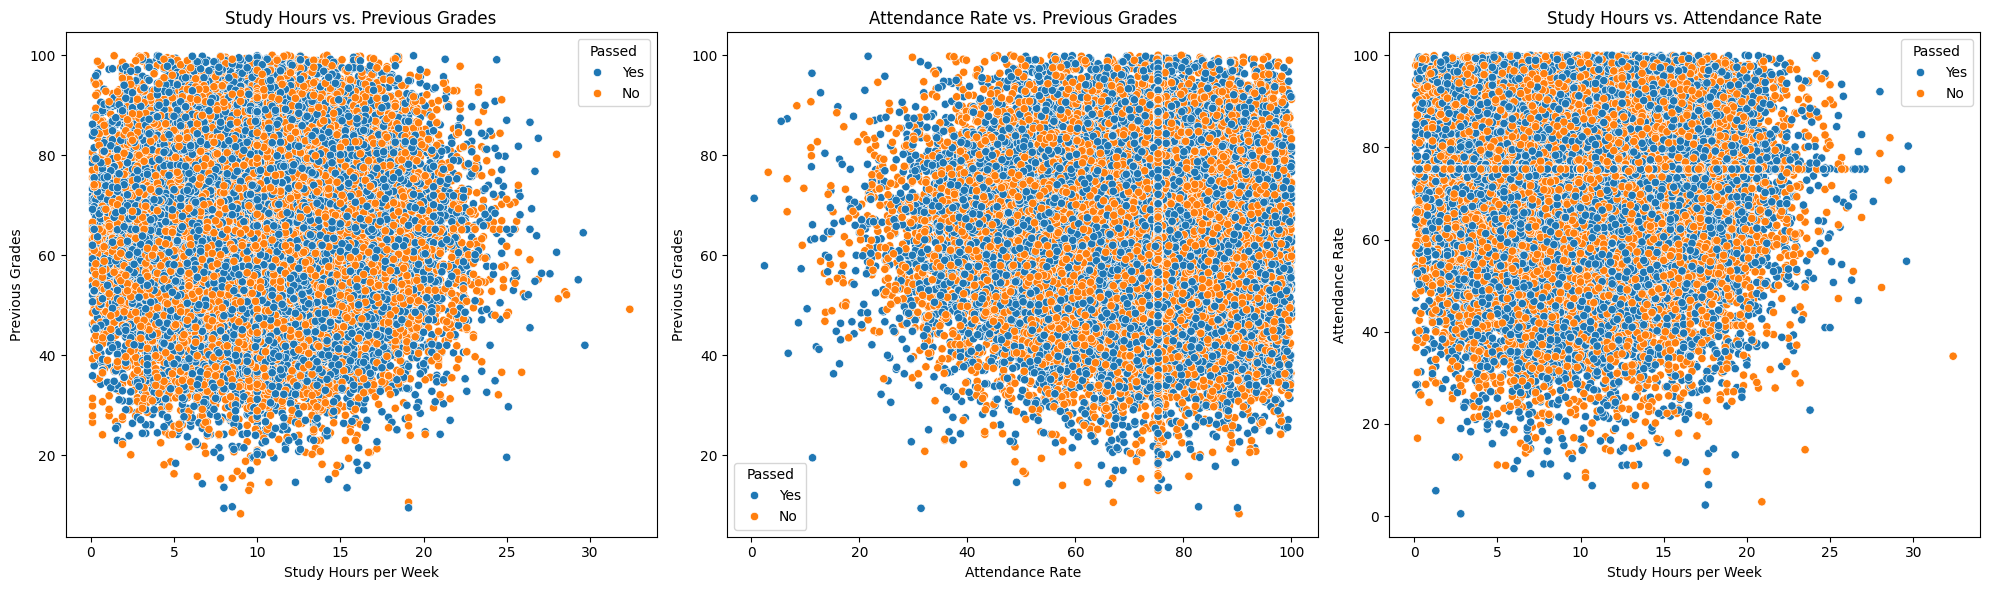

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with multiple subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6)) # 1 row, 3 columns, adjust figsize as needed

# Scatter plot 1: Study Hours per Week vs. Previous Grades
sns.scatterplot(x='Study Hours per Week', y='Previous Grades', hue='Passed', data=df, ax=axes[0])
axes[0].set_title('Study Hours vs. Previous Grades')
axes[0].set_xlabel('Study Hours per Week')
axes[0].set_ylabel('Previous Grades')

# Scatter plot 2: Attendance Rate vs. Previous Grades
sns.scatterplot(x='Attendance Rate', y='Previous Grades', hue='Passed', data=df, ax=axes[1])
axes[1].set_title('Attendance Rate vs. Previous Grades')
axes[1].set_xlabel('Attendance Rate')
axes[1].set_ylabel('Previous Grades')

# Scatter plot 3: Study Hours per Week vs. Attendance Rate
sns.scatterplot(x='Study Hours per Week', y='Attendance Rate', hue='Passed', data=df, ax=axes[2])
axes[2].set_title('Study Hours vs. Attendance Rate')
axes[2].set_xlabel('Study Hours per Week')
axes[2].set_ylabel('Attendance Rate')

# Use tight_layout to prevent labels and titles from overlapping
plt.tight_layout()

# Display the plots
plt.show()

From the above plot we can see that the students with the attendance rate in between 60-75% are the most ones passed

In [ ]:
df.head()

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed,study_hrs_bins,Attendance_bin
0,S00001,12.50,89.00,75.00,Yes,Master,Yes,10-15,86-100%
1,S00002,9.30,95.30,60.60,No,High School,No,5-10,86-100%
2,S00003,13.20,64.30,64.00,No,Associate,No,10-15,61-75%
3,S00004,17.60,76.80,62.40,Yes,Bachelor,No,15-20,76-85%
4,S00005,8.80,89.30,72.70,No,Master,No,5-10,86-100%


In [ ]:
df[df['Previous Grades'] < 0]
df['Previous Grades'] = df['Previous Grades'].round(1)

In [ ]:
df.head()

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed,study_hrs_bins,Attendance_bin
0,S00001,12.50,89.00,75.00,Yes,Master,Yes,10-15,86-100%
1,S00002,9.30,95.30,60.60,No,High School,No,5-10,86-100%
2,S00003,13.20,64.30,64.00,No,Associate,No,10-15,61-75%
3,S00004,17.60,76.80,62.40,Yes,Bachelor,No,15-20,76-85%
4,S00005,8.80,89.30,72.70,No,Master,No,5-10,86-100%


In [ ]:
prev_grades = df.groupby(['Previous Grades', 'Passed'], as_index=False).size()
passed_ = prev_grades[prev_grades['Passed'] == 'Yes']

In [ ]:
from plotly.graph_objs import XAxis
scatter = px.scatter(passed_, x='Previous Grades',
                      y='size',
                      title='Previous grades v/s passed',
                      color_continuous_scale='Aggrnyl',
                      color='Previous Grades')
scatter.update_layout(xaxis_title='Previous Grades',
                      yaxis_title='Passed',
                      xaxis_color='Green',
                      yaxis_color='Purple')
scatter.update_yaxes(range=[0, 100])
scatter.show()

In [ ]:
df[df['Parent Education Level'] == 'No Education']

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed,study_hrs_bins,Attendance_bin
13,S00014,0.40,75.10,50.40,No,No Education,Yes,0-5,76-85%
43,S00044,8.50,81.60,94.10,Yes,No Education,No,5-10,76-85%
53,S00054,13.10,75.30,68.60,No,No Education,Yes,10-15,76-85%
54,S00055,15.20,96.10,49.30,Yes,No Education,Yes,15-20,86-100%
57,S00058,8.50,73.60,60.10,Yes,No Education,No,5-10,61-75%
...,...,...,...,...,...,...,...,...,...
39902,S39903,6.00,74.50,81.50,Yes,No Education,Yes,5-10,61-75%
39904,S39905,10.30,65.30,51.00,No,No Education,Yes,10-15,61-75%
39928,S39929,14.40,79.80,51.10,No,No Education,Yes,10-15,76-85%
39986,S39987,18.20,75.30,75.50,No,No Education,Yes,15-20,76-85%


In [ ]:
passed_ones = df[df['Passed'] == 'Yes']

In [ ]:
p_edu = passed_ones.groupby('Parent Education Level', as_index=False).size()
p_edu

,Parent Education Level,size
0,Associate,3777
1,Bachelor,3893
2,Doctorate,3855
3,High School,3900
4,Master,3703
5,No Education,1008


In [ ]:
bar = px.bar(p_edu, x='Parent Education Level',
                       y='size',
                       title='Parent edu lev v/s Passed',
                       color='Parent Education Level')
bar.update_layout(xaxis_title='Parent Education Level', yaxis_title='Passed')
bar.show()